Goal is to see how the magnitude of an object after its mangled depends on the color difference between the input counts (with known spectra) and template used.

In [1]:
import numpy as np
import os
from utilities import *
import time
import pandas as pd

In [2]:
'''Finding counts from every template tested, takes ~3.5 min'''

#retreiving all template names
dir_list_2005 = os.listdir("../spectra/SN2005cs_modelspectra")
#remove non .fl files
dir_list_2005[:] = [i for i in dir_list_2005 if (i.endswith('.fl'))]
#add rest of file path
dir_list_2005 = ['SN2005cs_modelspectra/' + x for x in dir_list_2005]
        
#same process
dir_list_2006 = os.listdir("../spectra/SN2006bp_modelspectra")
dir_list_2006[:] = [i for i in dir_list_2006 if (i.endswith('.fl'))]
dir_list_2006 = ['SN2006bp_modelspectra/' + x for x in dir_list_2006]

#ask abt form of 2011 spectra, has third column

#make one big template array
dir_list = dir_list_2005 + dir_list_2006

#gather info from desired filters and each template
filterfiles_list = []   #the proper files for each filter for each template
zeropoint_list = []     #zeropoints for each template
pivot_list = []         #wavelengths around which each template can be mangled
desired_filter_list = ['UVW2', 'UVM2','UVW1',  'U', 'B', 'V']
for i in dir_list:
    temp1, temp2, temp3 = filterlist_to_filterfiles(desired_filter_list, i)
    filterfiles_list.append(temp1)
    zeropoint_list.append(temp2)
    pivot_list.append(temp3)

#more info for every template
wavelength_list = []    #all wavelengths with an associated flux for each template
flux_list = []          #flux in each filter for each template
counts_array = []       #number of counts in each filter for each template
for i,j,z in zip(dir_list, filterfiles_list, range(1,len(dir_list)+1)):
    print('processing template (', z, '/', len(dir_list), ')..')
    temp1, temp2, temp3 = total_counts(i,j)
    wavelength_list.append(temp1)
    flux_list.append(temp2)
    counts_array.append(temp3)
print('counts calculated for all templates')


processing template ( 1 / 23 )..
processing template ( 2 / 23 )..
processing template ( 3 / 23 )..
processing template ( 4 / 23 )..
processing template ( 5 / 23 )..
processing template ( 6 / 23 )..
processing template ( 7 / 23 )..
processing template ( 8 / 23 )..
processing template ( 9 / 23 )..
processing template ( 10 / 23 )..
processing template ( 11 / 23 )..
processing template ( 12 / 23 )..
processing template ( 13 / 23 )..
processing template ( 14 / 23 )..
processing template ( 15 / 23 )..
processing template ( 16 / 23 )..
processing template ( 17 / 23 )..
processing template ( 18 / 23 )..
processing template ( 19 / 23 )..
processing template ( 20 / 23 )..
processing template ( 21 / 23 )..
processing template ( 22 / 23 )..
processing template ( 23 / 23 )..
counts calculated for all templates


In [3]:
#info we now have
#all templates:
# file paths                        dir_list
# filterfiles                       filterfiles_list
# zeropoints                        zeropoint_list
# pivot wavelengths                 pivot_list
# wavelength arrays                 wavelenth_list
# flux arrays                       flux_list
# total counts across all filters   counts_array

#now finding inital magnitudes of each template
magnitude_list = []
for i,j,z in zip(counts_array,zeropoint_list, range(len(counts_array))):
    magnitude_list.append(countrates2mags_b(i,j))

#finding intial colors as well (M2-V)
color_list = []
for i in magnitude_list:
    color_list.append(i[1] - i[5])
    
#creating dataframe with all this info, named by dir_list
templates = {'File Paths':dir_list, 
             'Filter Files':filterfiles_list, 
             'Zero Points':zeropoint_list, 
             'Pivot Wavelengths':pivot_list,
             'Wavelengths': wavelength_list,
             'Flux':flux_list,
             'Counts': counts_array,
             'Magnitudes': magnitude_list,
             'Color': color_list}
templates = pd.DataFrame(templates)

print(templates['Color'])

0        [3.325962484393777]
1     [0.015195800665839698]
2      [-1.3126833872177812]
3        [5.378961819951723]
4      [-1.7471965929884554]
5        [4.025089619011769]
6       [0.6445480518005091]
7       [-1.755723213897383]
8        [4.413238860179206]
9        [4.082201661486685]
10     [-0.6338921525575181]
11      [-2.017380177006217]
12       [5.864003876352815]
13     [-2.3771808156989636]
14       [6.351936313687315]
15      [2.0703973733326926]
16     [-0.6324783440448627]
17     [-1.4148063909237152]
18       [6.118007591810734]
19       [5.358616346167793]
20       [4.215635772361953]
21     [-1.4809439151773844]
22     [-2.5875307260014573]
Name: Color, dtype: object


In [4]:
'''M2 - V'''
#structure of final arrays, first index is template being mangled, second is which other template was used as the input counts

#mangled magnitude array which holds the magnitudes of a template after its been mangled
#magnitude difference array which holds the difference in magnitudes of all six filters across all templates from before and after mangling,
# this is possible since we actually have the spectra of all inputs, whereas in practice we only have the input counts
#dimensions: # of templates, # of templates - 1
mangled_mags = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)
mag_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color array which holds M2-V color of every template after mangling
#dimensions: # of templates, # of templates - 1
mangled_colors = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color difference array holding (M2-V)_initial - (M2_V)_mangled
#dimensions: # of templates, # of templates - 1
color_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

'''loop (i,j), which checks every template against ever other, once as the template proper, and once as the counts to be mangled
    #if i==j, skip loop
    
    #mangle template j given template i's counts
    #determine new mangs after mangling
    #determine new color
    #add mag diff to magnitude difference array
    #add color diff to color difference array
    
    #now repeat using template j as input and template i as template
    
    #mangle template i to j's counts
    #determine new mags
    #determine new color
    #add mag diff
    #add color diff
'''
for i in range(len(templates['File Paths']) - 1):
    print('processing template (', i+1, '/', len(dir_list)-1, ')..')
    for j in range(len(templates['File Paths']) - 1): #change to same len as i loop once implemented
        if(i==j):
            mangled_mags[j,i] = np.zeros(6)
            mag_diff[j,i] = np.zeros(6)
            mangled_colors[j,i] = 0
            color_diff[j,i] = 0
            continue
        # template i is input counts, j is the actual template
        results = np.zeros(4, dtype=object) #holds mangle results while in loop
        results = mangle_simple(np.array(templates.loc[j,'Wavelengths']), 
                                templates.loc[j,'Flux'], 
                                templates.loc[j,'Filter Files'],
                                templates.loc[j,'Zero Points'],
                                templates.loc[j,'Pivot Wavelengths'],
                                np.array(templates.loc[i,'Counts']))
        #convert results to mangled mags
        #spectraWavelengths, mangledspectrumflux, temp_counts, speccounts_array
        mangled_mags[j,i] = countrates2mags_b(results[2], templates.loc[j,'Zero Points'])
        mag_diff[j,i] = mangled_mags[j,i] - templates.loc[i,'Magnitudes']
        #print("orig mag: \n", templates.loc[j,'Magnitudes'], "\nmangled mag: \n", mangled_mags[j,i])
        #print("difference: \n", mangled_mags[j,i] - templates.loc[j,'Magnitudes'])
        #print("difference again: \n", mag_diff[j,i])
        mangled_colors[j,i] = (mangled_mags[j,i][1] - mangled_mags[j,i][5]) #M2 - V
        #print(mangled_colors[j,i])
        #print(templates.loc[j,'Color'])
        color_diff[j,i] = templates.loc[i, 'Color'] - templates.loc[j, 'Color'] # difference in color of mangled and orig

processing template ( 1 / 22 )..
processing template ( 2 / 22 )..
processing template ( 3 / 22 )..
processing template ( 4 / 22 )..
processing template ( 5 / 22 )..
processing template ( 6 / 22 )..
processing template ( 7 / 22 )..
processing template ( 8 / 22 )..
processing template ( 9 / 22 )..
processing template ( 10 / 22 )..
processing template ( 11 / 22 )..
processing template ( 12 / 22 )..
processing template ( 13 / 22 )..
processing template ( 14 / 22 )..
processing template ( 15 / 22 )..
processing template ( 16 / 22 )..
processing template ( 17 / 22 )..
processing template ( 18 / 22 )..
processing template ( 19 / 22 )..
processing template ( 20 / 22 )..
processing template ( 21 / 22 )..
processing template ( 22 / 22 )..


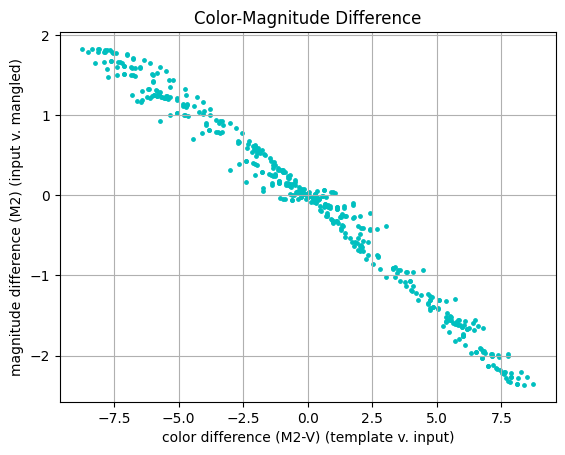

In [5]:
#plot results, color difference of templates () vs. magnitude difference of mangling
fig, ax = plt.subplots()


for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        if (i==j):
            continue
        ax.scatter(color_diff[i,j], mag_diff[i,j][1], c='c', s=6)
        
ax.set_title("Color-Magnitude Difference")
ax.set_xlabel('color difference (M2-V) (template v. input)')
ax.set_ylabel('magnitude difference (M2) (input v. mangled)')

plt.grid(True)
plt.show()

In [6]:
#plot results, color differnce of template and input v. magnitude difference of mangled mags and input mags
#j is template, i is input
color_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diffm2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        color_diff2[j,i] = (templates.loc[j,'Color'][0]) - (templates.loc[i,'Color'][0])
        mag_diff2[j,i] = mangled_mags[j,i][5] - templates.loc[i,'Magnitudes'][5]
        mag_diffm2[j,i] = mangled_mags[j,i][1] - templates.loc[i,'Magnitudes'][1]

/tmp/ipykernel_1361/3069586372.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag_diff2[j,i] = mangled_mags[j,i][5] - templates.loc[i,'Magnitudes'][5]
/tmp/ipykernel_1361/3069586372.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag_diffm2[j,i] = mangled_mags[j,i][1] - templates.loc[i,'Magnitudes'][1]


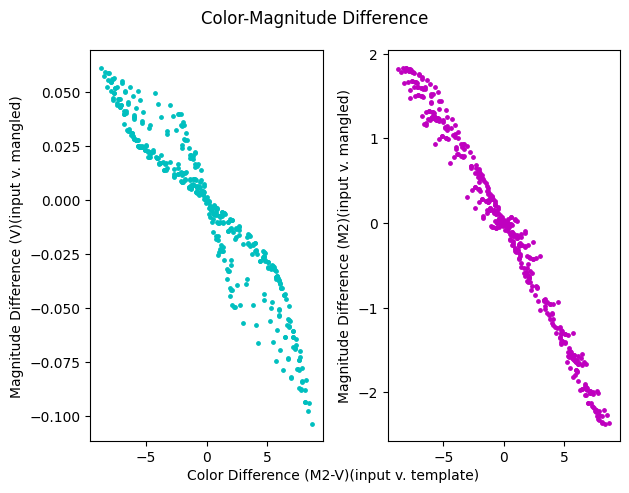

In [7]:
fig2, ax2 = plt.subplots(1,2, sharex=True)

for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        if (i==j):
            continue
        ax2[0].scatter(color_diff2[j,i], mag_diff2[j,i], c='c', s=6)
        ax2[1].scatter(color_diff[j,i], mag_diffm2[j,i], c='m', s=6)
        
fig2.suptitle("Color-Magnitude Difference")
fig2.text(0.3,0, 'Color Difference (M2-V)(input v. template)')
ax2[0].set_ylabel('Magnitude Difference (V)(input v. mangled)')
ax2[1].set_ylabel('Magnitude Difference (M2)(input v. mangled)')

plt.tight_layout()
plt.show()

In [ ]:
'''W1-B'''
#structure of final arrays, first index is template being mangled, second is which other template was used as the input counts

#mangled magnitude array which holds the magnitudes of a template after its been mangled
#magnitude difference array which holds the difference in magnitudes of all six filters across all templates from before and after mangling,
# this is possible since we actually have the spectra of all inputs, whereas in practice we only have the input counts
#dimensions: # of templates, # of templates - 1
mangled_mags = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)
mag_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color array which holds W1-B color of every template after mangling
#dimensions: # of templates, # of templates - 1
mangled_colors = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color difference array holding (W1-B)_initial - (W1-B)_mangled
#dimensions: # of templates, # of templates - 1
color_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

for i in range(len(templates['File Paths']) - 1):
    print('processing template (', i+1, '/', len(dir_list)-1, ')..')
    for j in range(len(templates['File Paths']) - 1): #change to same len as i loop once implemented
        if(i==j):
            mangled_mags[j,i] = np.zeros(6)
            mag_diff[j,i] = np.zeros(6)
            mangled_colors[j,i] = 0
            color_diff[j,i] = 0
            continue
        # template i is input counts, j is the actual template
        results = np.zeros(4, dtype=object) #holds mangle results while in loop
        results = mangle_simple(np.array(templates.loc[j,'Wavelengths']), 
                                templates.loc[j,'Flux'], 
                                templates.loc[j,'Filter Files'],
                                templates.loc[j,'Zero Points'],
                                templates.loc[j,'Pivot Wavelengths'],
                                np.array(templates.loc[i,'Counts']))
        #convert results to mangled mags
        #spectraWavelengths, mangledspectrumflux, temp_counts, speccounts_array
        mangled_mags[j,i] = countrates2mags_b(results[2], templates.loc[j,'Zero Points'])
        mag_diff[j,i] = mangled_mags[j,i] - templates.loc[i,'Magnitudes']
        mangled_colors[j,i] = (mangled_mags[j,i][2] - mangled_mags[j,i][4]) #W1 - B
        color_diff[j,i] = templates.loc[i, 'Color'] - templates.loc[j, 'Color'] # difference in color of mangled and orig

processing template ( 1 / 22 )..
processing template ( 2 / 22 )..
processing template ( 3 / 22 )..
processing template ( 4 / 22 )..
processing template ( 5 / 22 )..
processing template ( 6 / 22 )..
processing template ( 7 / 22 )..
processing template ( 8 / 22 )..
processing template ( 9 / 22 )..
processing template ( 10 / 22 )..
processing template ( 11 / 22 )..
processing template ( 12 / 22 )..
processing template ( 13 / 22 )..
processing template ( 14 / 22 )..
processing template ( 15 / 22 )..
processing template ( 16 / 22 )..
processing template ( 17 / 22 )..
processing template ( 18 / 22 )..
processing template ( 19 / 22 )..
processing template ( 20 / 22 )..
processing template ( 21 / 22 )..
processing template ( 22 / 22 )..


In [10]:
#plot results, color differnce of template and input v. magnitude difference of mangled mags and input mags
#j is template, i is input
color_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diffm2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        color_diff2[j,i] = (templates.loc[j,'Color'][0]) - (templates.loc[i,'Color'][0])
        mag_diff2[j,i] = mangled_mags[j,i][4] - templates.loc[i,'Magnitudes'][4]
        mag_diffm2[j,i] = mangled_mags[j,i][2] - templates.loc[i,'Magnitudes'][2]

/tmp/ipykernel_1361/1672958522.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag_diff2[j,i] = mangled_mags[j,i][4] - templates.loc[i,'Magnitudes'][4]
/tmp/ipykernel_1361/1672958522.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag_diffm2[j,i] = mangled_mags[j,i][2] - templates.loc[i,'Magnitudes'][2]


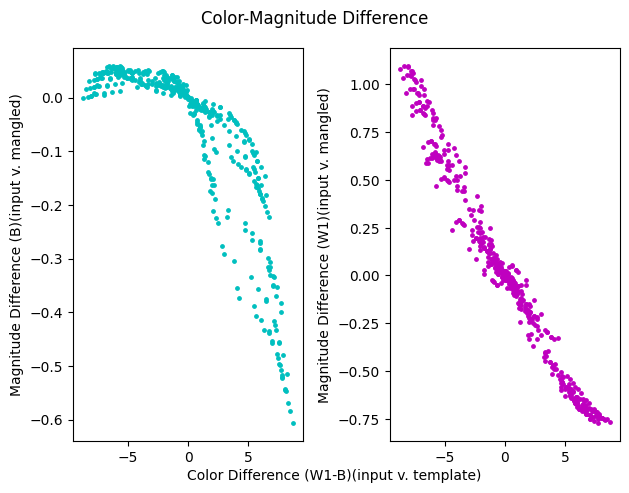

In [11]:
fig2, ax2 = plt.subplots(1,2, sharex=True)

for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        if (i==j):
            continue
        ax2[0].scatter(color_diff2[j,i], mag_diff2[j,i], c='c', s=6)
        ax2[1].scatter(color_diff[j,i], mag_diffm2[j,i], c='m', s=6)
        
fig2.suptitle("Color-Magnitude Difference")
fig2.text(0.3,0, 'Color Difference (W1-B)(input v. template)')
ax2[0].set_ylabel('Magnitude Difference (B)(input v. mangled)')
ax2[1].set_ylabel('Magnitude Difference (W1)(input v. mangled)')

plt.tight_layout()
plt.show()

In [12]:
'''B-V'''
#structure of final arrays, first index is template being mangled, second is which other template was used as the input counts

#mangled magnitude array which holds the magnitudes of a template after its been mangled
#magnitude difference array which holds the difference in magnitudes of all six filters across all templates from before and after mangling,
# this is possible since we actually have the spectra of all inputs, whereas in practice we only have the input counts
#dimensions: # of templates, # of templates - 1
mangled_mags = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)
mag_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color array which holds B-V color of every template after mangling
#dimensions: # of templates, # of templates - 1
mangled_colors = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

#color difference array holding (B-V)_initial - (B-v)_mangled
#dimensions: # of templates, # of templates - 1
color_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

for i in range(len(templates['File Paths']) - 1):
    print('processing template (', i+1, '/', len(dir_list)-1, ')..')
    for j in range(len(templates['File Paths']) - 1): #change to same len as i loop once implemented
        if(i==j):
            mangled_mags[j,i] = np.zeros(6)
            mag_diff[j,i] = np.zeros(6)
            mangled_colors[j,i] = 0
            color_diff[j,i] = 0
            continue
        # template i is input counts, j is the actual template
        results = np.zeros(4, dtype=object) #holds mangle results while in loop
        results = mangle_simple(np.array(templates.loc[j,'Wavelengths']), 
                                templates.loc[j,'Flux'], 
                                templates.loc[j,'Filter Files'],
                                templates.loc[j,'Zero Points'],
                                templates.loc[j,'Pivot Wavelengths'],
                                np.array(templates.loc[i,'Counts']))
        #convert results to mangled mags
        #spectraWavelengths, mangledspectrumflux, temp_counts, speccounts_array
        mangled_mags[j,i] = countrates2mags_b(results[2], templates.loc[j,'Zero Points'])
        mag_diff[j,i] = mangled_mags[j,i] - templates.loc[i,'Magnitudes']
        mangled_colors[j,i] = (mangled_mags[j,i][4] - mangled_mags[j,i][5]) #B-V
        color_diff[j,i] = templates.loc[i, 'Color'] - templates.loc[j, 'Color'] # difference in color of mangled and orig

processing template ( 1 / 22 )..
processing template ( 2 / 22 )..
processing template ( 3 / 22 )..
processing template ( 4 / 22 )..
processing template ( 5 / 22 )..
processing template ( 6 / 22 )..
processing template ( 7 / 22 )..
processing template ( 8 / 22 )..
processing template ( 9 / 22 )..
processing template ( 10 / 22 )..
processing template ( 11 / 22 )..
processing template ( 12 / 22 )..
processing template ( 13 / 22 )..
processing template ( 14 / 22 )..
processing template ( 15 / 22 )..
processing template ( 16 / 22 )..
processing template ( 17 / 22 )..
processing template ( 18 / 22 )..
processing template ( 19 / 22 )..
processing template ( 20 / 22 )..
processing template ( 21 / 22 )..
processing template ( 22 / 22 )..


/tmp/ipykernel_1361/1874439043.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag_diff2[j,i] = mangled_mags[j,i][5] - templates.loc[i,'Magnitudes'][5]
/tmp/ipykernel_1361/1874439043.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mag_diffm2[j,i] = mangled_mags[j,i][4] - templates.loc[i,'Magnitudes'][4]


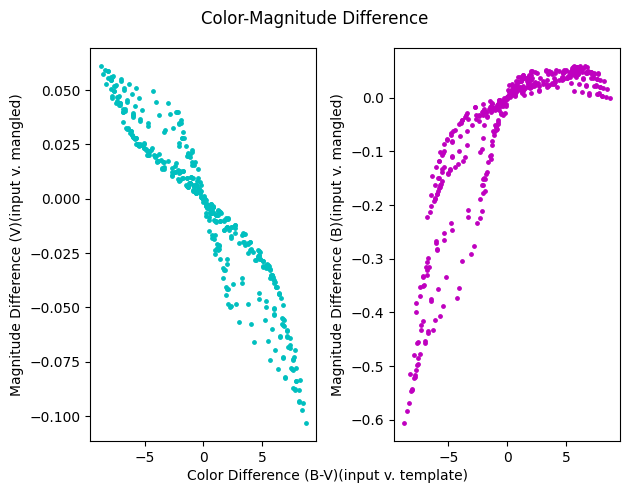

In [13]:
#plot results, color differnce of template and input v. magnitude difference of mangled mags and input mags
#j is template, i is input
color_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diff2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
mag_diffm2 = np.zeros((color_diff.shape[1], color_diff.shape[1]))
for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        color_diff2[j,i] = (templates.loc[j,'Color'][0]) - (templates.loc[i,'Color'][0])
        mag_diff2[j,i] = mangled_mags[j,i][5] - templates.loc[i,'Magnitudes'][5]
        mag_diffm2[j,i] = mangled_mags[j,i][4] - templates.loc[i,'Magnitudes'][4]
        
fig2, ax2 = plt.subplots(1,2, sharex=True)

for i in range(color_diff.shape[1]):
    for j in range(color_diff.shape[1]):
        if (i==j):
            continue
        ax2[0].scatter(color_diff2[j,i], mag_diff2[j,i], c='c', s=6)
        ax2[1].scatter(color_diff[j,i], mag_diffm2[j,i], c='m', s=6)
        
fig2.suptitle("Color-Magnitude Difference")
fig2.text(0.3,0, 'Color Difference (B-V)(input v. template)')
ax2[0].set_ylabel('Magnitude Difference (V)(input v. mangled)')
ax2[1].set_ylabel('Magnitude Difference (B)(input v. mangled)')

plt.tight_layout()
plt.show()

In [ ]:
'''FInish function and clean up previous cells'''
def color_mag_difference(left_filter_index, right_filter_index, template_df):
    #structure of final arrays, first index is template being mangled, second is which other template was used as the input counts

    #mangled magnitude array which holds the magnitudes of a template after its been mangled
    #magnitude difference array which holds the difference in magnitudes of all six filters across all templates from before and after mangling,
    # this is possible since we actually have the spectra of all inputs, whereas in practice we only have the input counts
    #dimensions: # of templates, # of templates - 1
    mangled_mags = np.zeros((len(template_df['File Paths']), len(template_df["File Paths"]) - 1), dtype=object)
    mag_diff = np.zeros((len(template_df['File Paths']), len(template_df["File Paths"]) - 1), dtype=object)

    #array which holds color of every template after mangling
    #dimensions: # of templates, # of templates - 1
    mangled_colors = np.zeros((len(template_df['File Paths']), len(template_df["File Paths"]) - 1), dtype=object)

    #color difference array holding (B-V)_initial - (B-v)_mangled
    #dimensions: # of templates, # of templates - 1
    color_diff = np.zeros((len(templates['File Paths']), len(templates["File Paths"]) - 1), dtype=object)

    for i in range(len(templates['File Paths']) - 1):
        print('processing template (', i+1, '/', len(dir_list)-1, ')..')
        for j in range(len(templates['File Paths']) - 1): #change to same len as i loop once implemented
            if(i==j):
                mangled_mags[j,i] = np.zeros(6)
                mag_diff[j,i] = np.zeros(6)
                mangled_colors[j,i] = 0
                color_diff[j,i] = 0
                continue
            # template i is input counts, j is the actual template
            results = np.zeros(4, dtype=object) #holds mangle results while in loop
            results = mangle_simple(np.array(templates.loc[j,'Wavelengths']), 
                                    templates.loc[j,'Flux'], 
                                    templates.loc[j,'Filter Files'],
                                    templates.loc[j,'Zero Points'],
                                    templates.loc[j,'Pivot Wavelengths'],
                                    np.array(templates.loc[i,'Counts']))
            #convert results to mangled mags
            #spectraWavelengths, mangledspectrumflux, temp_counts, speccounts_array
            mangled_mags[j,i] = countrates2mags_b(results[2], templates.loc[j,'Zero Points'])
            mag_diff[j,i] = mangled_mags[j,i] - templates.loc[i,'Magnitudes']
            mangled_colors[j,i] = (mangled_mags[j,i][4] - mangled_mags[j,i][5]) #B-V
            color_diff[j,i] = templates.loc[i, 'Color'] - templates.loc[j, 'Color'] # difference in color of mangled and orig